In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_beras = pd.read_excel(
    "/content/drive/MyDrive/dataset/tubesadw/Data_Beras2.xlsx"
)

data_inflasi = pd.read_csv(
    "/content/drive/MyDrive/dataset/tubesadw/inflasi_mom_nasional_2006_2025.csv"
)

In [ ]:
data_beras

,Tanggal,Harga_Beras_Grosir
0,2014-01-01,9433.17
1,2014-02-01,9531.20
2,2014-03-01,9595.89
3,2014-04-01,9424.65
4,2014-05-01,9413.91
...,...,...
127,2024-08-01,13600.00
128,2024-09-01,13611.00
129,2024-10-01,13563.00
130,2024-11-01,13453.00


In [ ]:
data_inflasi

,Tanggal,Inflation_MoM
0,2006-01-01,1.36
1,2006-02-01,0.58
2,2006-03-01,0.03
3,2006-04-01,0.05
4,2006-05-01,0.37
...,...,...
234,2025-07-01,0.30
235,2025-08-01,-0.08
236,2025-09-01,0.21
237,2025-10-01,0.28


In [ ]:
# Harga beras
data_beras['Tanggal'] = pd.to_datetime(data_beras['Tanggal'], format='%Y-%m')
data_beras = data_beras.sort_values('Tanggal')

# Inflasi
data_inflasi['Tanggal'] = pd.to_datetime(data_inflasi['Date'])
data_inflasi = data_inflasi[['Tanggal', 'Inflation_MoM']]

# Merge
df = data_beras.merge(data_inflasi, on='Tanggal', how='left')
df = df.set_index('Tanggal').sort_index()

# Subset periode analisis
df = df.loc['2018-01-01':'2024-12-01']

#Dummy

In [ ]:
# Dummy Lebaran (bulan Lebaran & 1 bulan sebelum)
lebaran = {
    2018: 6, 2019: 6,
    2020: 5, 2021: 5,
    2022: 5, 2023: 4,
    2024: 4
}

df['Dummy_Lebaran'] = 0
for year, month in lebaran.items():
    mask = (
        (df.index.year == year) &
        (df.index.month.isin([month, month-1]))
    )
    df.loc[mask, 'Dummy_Lebaran'] = 1

# Dummy COVID Shock
df['Dummy_COVID'] = (
    (df.index >= '2020-03-01') & (df.index <= '2021-03-01')
).astype(int)

# Import Regime (ordinal)
df['Import_Regime'] = 0
df.loc[(df.index.year >= 2021) & (df.index.year <= 2022), 'Import_Regime'] = 1
df.loc[df.index.year >= 2023, 'Import_Regime'] = 2

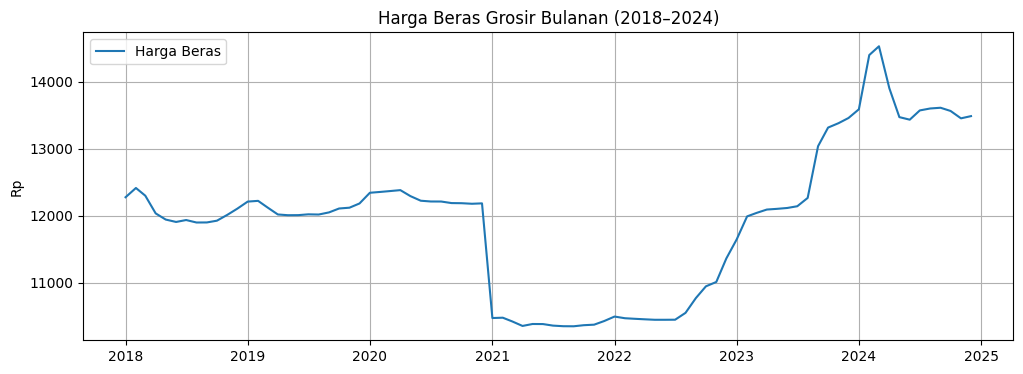

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(df.index, df['Harga_Beras_Grosir'], label='Harga Beras')
plt.title('Harga Beras Grosir Bulanan (2018–2024)')
plt.ylabel('Rp')
plt.grid(True)
plt.legend()
plt.show()

#ADF TEST & DIFFERENCING

In [ ]:
def adf_test(series, title=''):
    result = adfuller(series.dropna())
    print(title)
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    print("-"*40)

adf_test(df['Harga_Beras_Grosir'], "ADF Level")
adf_test(df['Harga_Beras_Grosir'].diff(), "ADF First Difference")

ADF Level
ADF Statistic : -0.9948
p-value       : 0.7552
----------------------------------------
ADF First Difference
ADF Statistic : -7.2750
p-value       : 0.0000
----------------------------------------


In [ ]:
df['Delta_Harga'] = df['Harga_Beras_Grosir'].diff()

#ACF PACF

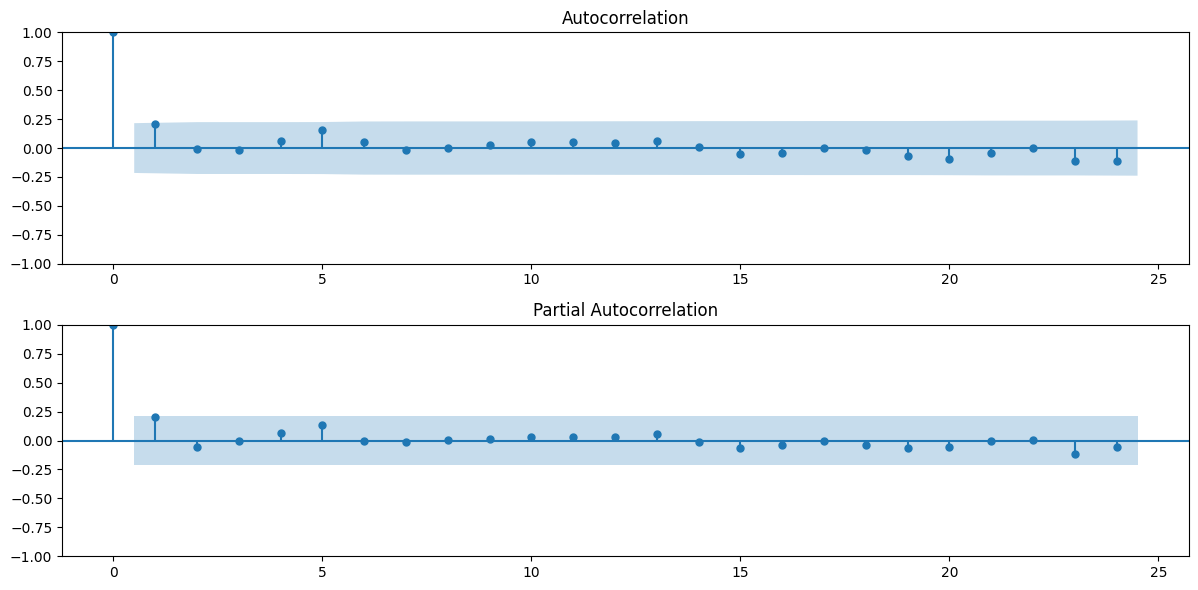

In [ ]:
fig, ax = plt.subplots(2,1, figsize=(12,6))
plot_acf(df['Delta_Harga'].dropna(), ax=ax[0], lags=24)
plot_pacf(df['Delta_Harga'].dropna(), ax=ax[1], lags=24)
plt.tight_layout()
plt.show()

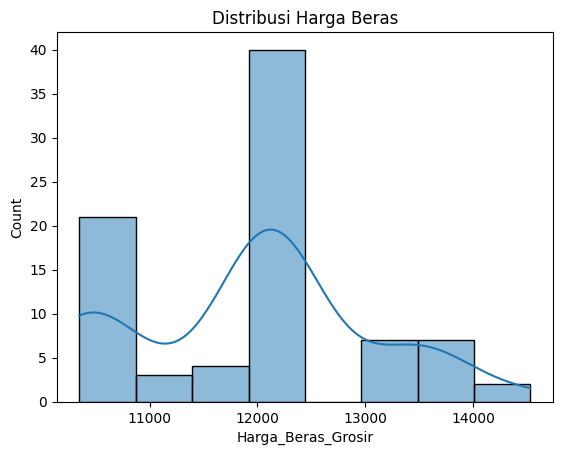

In [ ]:
sns.histplot(df['Harga_Beras_Grosir'], kde=True)
plt.title("Distribusi Harga Beras")
plt.show()

#Split Data

In [ ]:
y = df['Delta_Harga'].dropna()

exog = df.loc[y.index, [
    'Inflation_MoM',
    'Dummy_Lebaran',
    'Dummy_COVID',
    'Import_Regime'
]]

train_size = int(len(y) * 0.8)

y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
exog_train, exog_test = exog.iloc[:train_size], exog.iloc[train_size:]

#TSR

In [ ]:
df['trend'] = np.arange(len(df))

X_tsr = df.loc[y.index, [
    'trend',
    'Inflation_MoM',
    'Dummy_Lebaran',
    'Dummy_COVID',
    'Import_Regime'
]]
X_tsr = sm.add_constant(X_tsr)

X_train, X_test = X_tsr.iloc[:train_size], X_tsr.iloc[train_size:]

tsr_model = sm.OLS(y_train, X_train).fit()
print(tsr_model.summary())

                            OLS Regression Results                            
Dep. Variable:            Delta_Harga   R-squared:                       0.205
Model:                            OLS   Adj. R-squared:                  0.139
Method:                 Least Squares   F-statistic:                     3.104
Date:                Sun, 28 Dec 2025   Prob (F-statistic):             0.0148
Time:                        14:54:28   Log-Likelihood:                -445.76
No. Observations:                  66   AIC:                             903.5
Df Residuals:                      60   BIC:                             916.7
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          -112.7690     70.294     -1.604

#SARIMAX

                               SARIMAX Results                                
Dep. Variable:            Delta_Harga   No. Observations:                   66
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -436.833
Date:                Sun, 28 Dec 2025   AIC                            887.666
Time:                        14:54:29   BIC                            902.778
Sample:                    02-01-2018   HQIC                           893.619
                         - 07-01-2023                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Inflation_MoM    61.4470    192.876      0.319      0.750    -316.584     439.478
Dummy_Lebaran   -10.9149    240.490     -0.045      0.964    -482.266     460.436
Dummy_COVID    -155.4930    123.555     

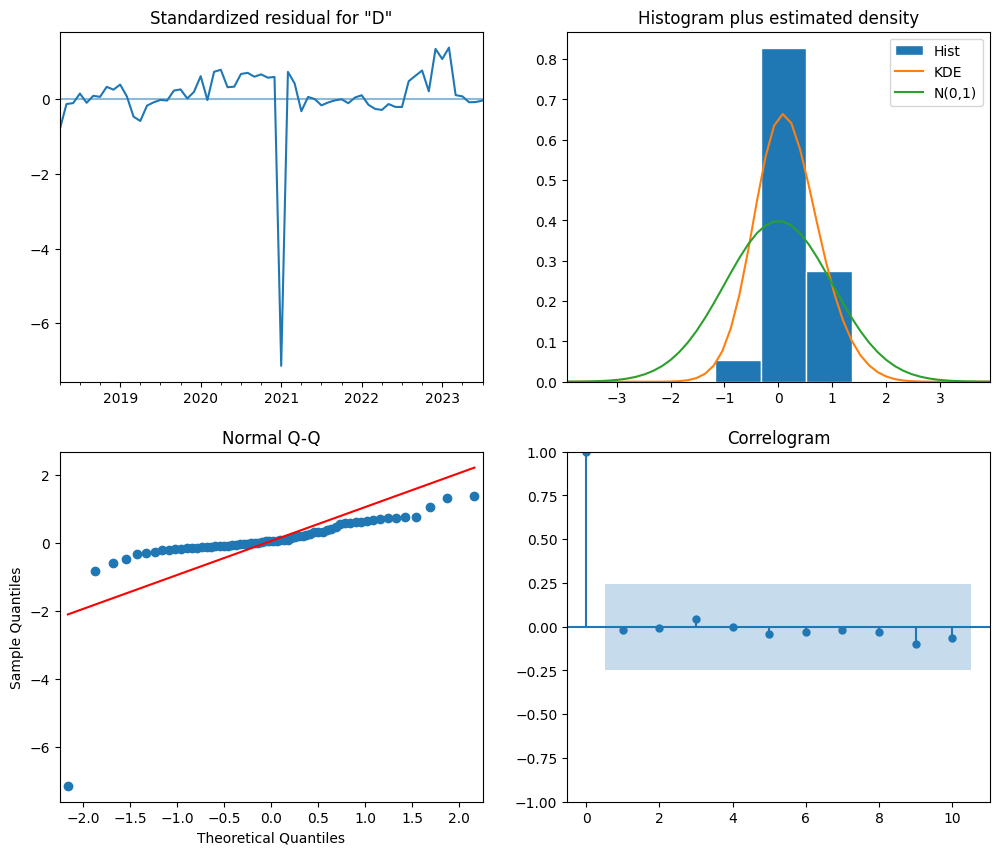

In [ ]:
sarimax_model = SARIMAX(
    y_train,
    exog=exog_train,
    order=(1,0,1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_result = sarimax_model.fit(disp=False)
print(sarimax_result.summary())

sarimax_result.plot_diagnostics(figsize=(12,10))
plt.show()

sarimax_pred = sarimax_result.predict(
    start=y_test.index[0],
    end=y_test.index[-1],
    exog=exog_test
)

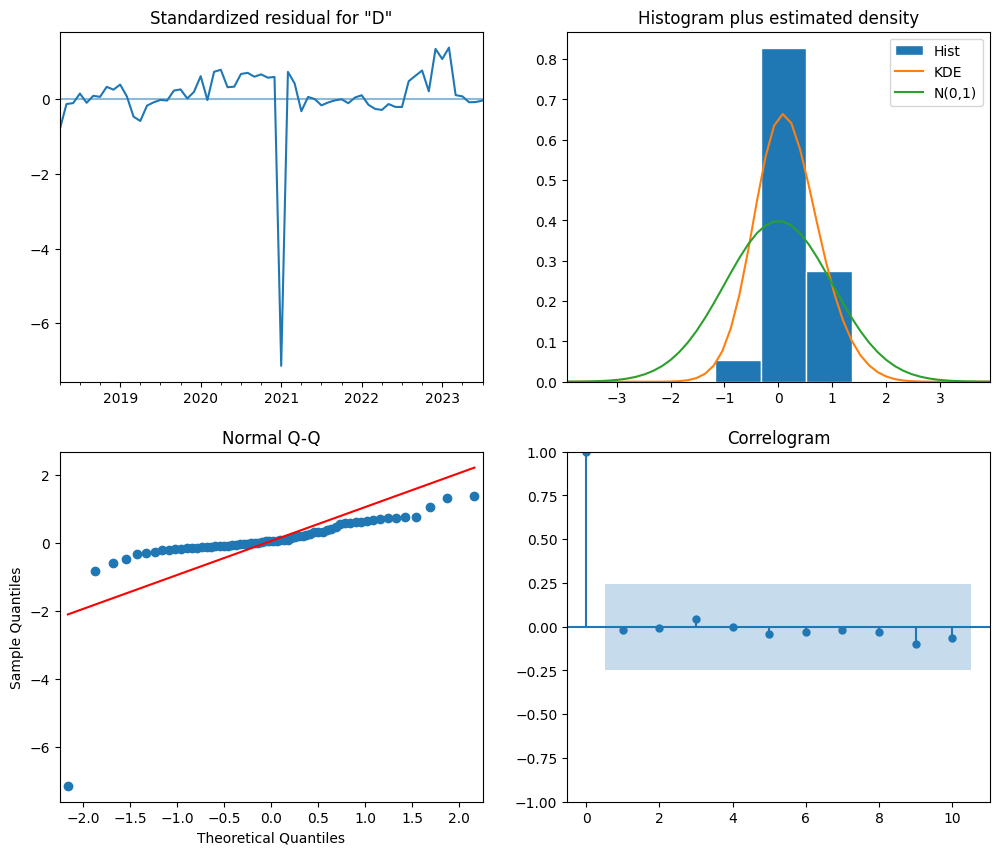

In [ ]:
sarimax_result.plot_diagnostics(figsize=(12,10))
plt.show()

#HYBRID

In [ ]:
sarimax_fitted = sarimax_result.fittedvalues
residual = y_train - sarimax_fitted

X_res_train = sm.add_constant(exog_train, has_constant='add')
res_model = sm.OLS(residual, X_res_train).fit()

X_res_test = sm.add_constant(exog_test, has_constant='add')
residual_pred = res_model.predict(X_res_test)

hybrid_pred = sarimax_pred + residual_pred

In [ ]:
harga_awal = df.loc[y.index, 'Harga_Beras_Grosir'].iloc[train_size-1]

tsr_price = harga_awal + np.cumsum(tsr_model.predict(X_test))
sarimax_price = harga_awal + np.cumsum(sarimax_pred)
hybrid_price = harga_awal + np.cumsum(hybrid_pred)

y_actual = df.loc[y_test.index, 'Harga_Beras_Grosir']

#EVALUASI

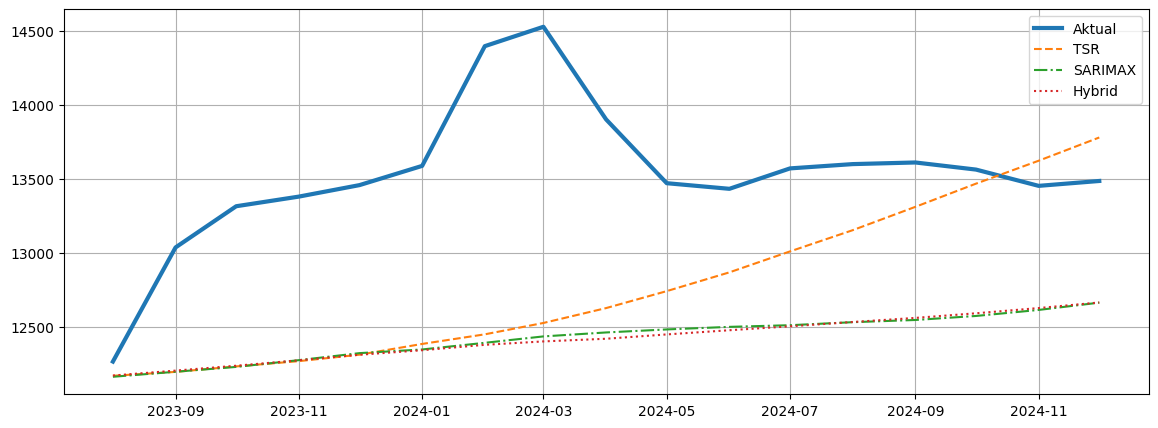

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(y_actual.index, y_actual, label='Aktual', linewidth=3)
plt.plot(y_actual.index, tsr_price, '--', label='TSR')
plt.plot(y_actual.index, sarimax_price, '-.', label='SARIMAX')
plt.plot(y_actual.index, hybrid_price, ':', label='Hybrid')
plt.legend()
plt.grid(True)
plt.show()
